# Treatment of CSV file

Import and definition of variables

In [7]:
import os
import re
import pandas as pd
import numpy as np
import pyarrow as pa

# Directory Setup
BASE_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in locals() else "."
BRONZE_DIR = os.path.join(BASE_DIR, "data", "1_bronze")
SILVER_DIR = os.path.join(BASE_DIR, "data", "2_silver")
GOLD_DIR = os.path.join(BASE_DIR, "data", "3_gold")

print(f"BASE_DIR: {BASE_DIR}")
print(f"BRONZE_DIR: {BRONZE_DIR}")
print(f"SILVER_DIR: {SILVER_DIR}")
print(f"GOLD_DIR: {GOLD_DIR}")

for folder in [BRONZE_DIR, SILVER_DIR, GOLD_DIR]:
    os.makedirs(folder, exist_ok=True)

# Work around repeated notebook execution collisions in pyarrow/pandas
for ext_name in ["pandas.period", "pandas.interval"]:
    try:
        pa.unregister_extension_type(ext_name)
    except Exception:
        pass

BASE_DIR: .
BRONZE_DIR: .\data\1_bronze
SILVER_DIR: .\data\2_silver
GOLD_DIR: .\data\3_gold


# STEP 1: BRONZE TO SILVER (Extraction, Data Cleaning & Type Casting)

In [2]:
def bronze_to_silver(input_csv_path: str):
    print("--- [1/2] Processing Bronze -> Silver ---")
    
    # Read raw lines to extract data boundaries
    with open(input_csv_path, 'r', encoding='utf-8', errors='ignore') as f:
        lines = f.readlines()

    # Data block spans from line 10 to 38
    data_rows = []
    for line in lines[10:39]:
        parts = [p.strip() for p in line.strip().split(';')]
        if len(parts) > 0 and parts[0] != '':
            data_rows.append(parts[:16])

    # Standardized Column Headers
    cols = [
        'location_raw',
        'homicidio_doloso_2024', 'homicidio_doloso_2025',
        'latrocinio_2024', 'latrocinio_2025',
        'lesao_corporal_morte_2024', 'lesao_corporal_morte_2025',
        'policiais_vitimas_2024', 'policiais_vitimas_2025',
        'intervencao_policial_2024', 'intervencao_policial_2025',
        'mvi_absoluto_2024', 'mvi_absoluto_2025',
        'mvi_taxa_2024', 'mvi_taxa_2025',
        'mvi_variacao_pct'
    ]

    df_raw = pd.DataFrame(data_rows, columns=cols)

    # Cleaning Helper Functions
    def clean_num(val):
        if pd.isna(val) or val is None:
            return np.nan
        s = str(val).strip()
        if s in ['-', '', '(-)', 'NaN', 'None']:
            return np.nan
        # Strip space thousands separator, convert comma to decimal point
        s = s.replace(' ', '').replace(',', '.')
        try:
            return float(s)
        except ValueError:
            return np.nan

    def clean_location(val):
        if pd.isna(val):
            return val
        # Strip footnote markers like '(4)' or '(5)'
        return re.sub(r'\s*\(\d+\)', '', str(val)).strip()

    # Clean text and numbers
    df_silver = df_raw.copy()
    df_silver['location'] = df_silver['location_raw'].apply(clean_location)
    df_silver.drop(columns=['location_raw'], inplace=True)
    
    num_cols = [c for c in df_silver.columns if c != 'location']
    for col in num_cols:
        df_silver[col] = df_silver[col].apply(clean_num)

    # Export to Silver Layer as Parquet with CSV fallback
    silver_output = os.path.join(SILVER_DIR, "cleaned_mvi_wide.parquet")
    csv_output = os.path.join(SILVER_DIR, "cleaned_mvi_wide.csv")
    df_silver.to_parquet(silver_output, engine='fastparquet', index=False)
    df_silver.to_csv(csv_output, index=False, encoding='utf-8')
    print(f"Silver table saved to: {silver_output} ({len(df_silver)} rows)")
    return silver_output

# STEP 2: SILVER TO GOLD (Normalization into Star Schema)

In [3]:
def silver_to_gold(silver_file_path: str):
    print("\n--- [2/2] Processing Silver -> Gold ---")
    # df_silver = pd.read_csv(silver_file_path, encoding='utf-8')
    df_silver = pd.read_parquet(silver_file_path, engine='fastparquet')

    # 1. Dimension: Location
    region_map = {
        'Acre': 'Norte', 'Amapá': 'Norte', 'Amazonas': 'Norte', 'Pará': 'Norte', 
        'Rondônia': 'Norte', 'Roraima': 'Norte', 'Tocantins': 'Norte',
        'Alagoas': 'Nordeste', 'Bahia': 'Nordeste', 'Ceará': 'Nordeste', 
        'Maranhão': 'Nordeste', 'Paraíba': 'Nordeste', 'Pernambuco': 'Nordeste', 
        'Piauí': 'Nordeste', 'Rio Grande do Norte': 'Nordeste', 'Sergipe': 'Nordeste',
        'Distrito Federal': 'Centro-Oeste', 'Goiás': 'Centro-Oeste', 
        'Mato Grosso': 'Centro-Oeste', 'Mato Grosso do Sul': 'Centro-Oeste',
        'Espírito Santo': 'Sudeste', 'Minas Gerais': 'Sudeste', 
        'Rio de Janeiro': 'Sudeste', 'São Paulo': 'Sudeste',
        'Paraná': 'Sul', 'Rio Grande do Sul': 'Sul', 'Santa Catarina': 'Sul',
        'Brasil': 'Nacional'
    }

    df_loc = df_silver[['location']].drop_duplicates().reset_index(drop=True)
    df_loc['location_id'] = df_loc.index + 1
    df_loc['location_name'] = df_loc['location']
    df_loc['is_national'] = df_loc['location_name'] == 'Brasil'
    df_loc['region'] = df_loc['location_name'].map(region_map)
    dim_location = df_loc[['location_id', 'location_name', 'region', 'is_national']]

    # 2. Dimension: Metric Metadata
    dim_metric = pd.DataFrame([
        {'metric_id': 1, 'metric_code': 'homicidio_doloso', 'metric_name': 'Homicídio Doloso', 'unit': 'Absoluto'},
        {'metric_id': 2, 'metric_code': 'latrocinio', 'metric_name': 'Latrocínio', 'unit': 'Absoluto'},
        {'metric_id': 3, 'metric_code': 'lesao_corporal_morte', 'metric_name': 'Lesão Corporal Seguida de Morte', 'unit': 'Absoluto'},
        {'metric_id': 4, 'metric_code': 'policiais_vitimas', 'metric_name': 'Policiais Vítimas de CVLI', 'unit': 'Absoluto'},
        {'metric_id': 5, 'metric_code': 'intervencao_policial', 'metric_name': 'Morte por Intervenção Policial', 'unit': 'Absoluto'},
        {'metric_id': 6, 'metric_code': 'mvi_absoluto', 'metric_name': 'Total MVI', 'unit': 'Absoluto'},
        {'metric_id': 7, 'metric_code': 'mvi_taxa', 'metric_name': 'Taxa MVI por 100k hab.', 'unit': 'Taxa per 100k'},
    ])

    # 3. Fact Table: Unpivoting Metrics for 2024 and 2025
    fact_records = []
    metric_lookup = dict(zip(dim_metric['metric_code'], dim_metric['metric_id']))
    loc_lookup = dict(zip(dim_location['location_name'], dim_location['location_id']))

    metrics = list(metric_lookup.keys())

    for _, row in df_silver.iterrows():
        loc_id = loc_lookup[row['location']]
        for year in [2024, 2025]:
            for m_code in metrics:
                col_name = f"{m_code}_{year}"
                val = row[col_name]
                fact_records.append({
                    'location_id': loc_id,
                    'metric_id': metric_lookup[m_code],
                    'year': year,
                    'value': val
                })

    fct_mvi = pd.DataFrame(fact_records)

    # Export Gold Star Schema
    dim_location.to_parquet(os.path.join(GOLD_DIR, "dim_location.parquet"), index=False)
    dim_metric.to_parquet(os.path.join(GOLD_DIR, "dim_metric.parquet"), index=False)
    fct_mvi.to_parquet(os.path.join(GOLD_DIR, "fct_mvi.parquet"), index=False)

    print("Gold Star Schema created successfully:")
    print(f"  - dim_location.parquet ({len(dim_location)} rows)")
    print(f"  - dim_metric.parquet ({len(dim_metric)} rows)")
    print(f"  - fct_mvi.parquet ({len(fct_mvi)} rows)")

In [ ]:
raw_file = os.path.join(BRONZE_DIR, "T01-MVI-anuario-2026.csv")
print(f"Checking for raw file at: {raw_file}")
if os.path.exists(raw_file):
    silver_file = bronze_to_silver(raw_file)
    print(f"Silver file created at: {silver_file}")
    silver_to_gold(silver_file)
else:
    print(f"Please place 'anuario-2026.csv' into: {BRONZE_DIR}")

Checking for raw file at: .\data\1_bronze\T01-MVI-anuario-2026.csv
--- [1/2] Processing Bronze -> Silver ---
Silver table saved to: .\data\2_silver\cleaned_mvi_wide.parquet (28 rows)
Silver file created at: .\data\2_silver\cleaned_mvi_wide.parquet

--- [2/2] Processing Silver -> Gold ---
Gold Star Schema created successfully:
  - dim_location.parquet (28 rows)
  - dim_metric.parquet (7 rows)
  - fct_mvi.parquet (392 rows)


Data AnalysisÇ Queryng the Gold Layer

In [5]:
import duckdb

con = duckdb.connect()

# Query 1: Top 5 States with highest MVI rate in 2025
top5_query = """
SELECT 
    l.location_name AS state,
    l.region,
    f.value AS mvi_rate_2025
FROM 'data/3_gold/fct_mvi.parquet' f
JOIN 'data/3_gold/dim_location.parquet' l ON f.location_id = l.location_id
JOIN 'data/3_gold/dim_metric.parquet' m ON f.metric_id = m.metric_id
WHERE m.metric_code = 'mvi_taxa' 
  AND f.year = 2025 
  AND l.is_national = FALSE
ORDER BY mvi_rate_2025 DESC
LIMIT 5;
"""

print("--- Top 5 States by MVI Rate (2025) ---")
print(con.execute(top5_query).df())

# Query 2: Regional aggregation of total MVI deaths in 2024 vs 2025
region_query = """
SELECT 
    l.region,
    f.year,
    SUM(f.value) AS total_mvi_deaths
FROM 'data/3_gold/fct_mvi.parquet' f
JOIN 'data/3_gold/dim_location.parquet' l ON f.location_id = l.location_id
JOIN 'data/3_gold/dim_metric.parquet' m ON f.metric_id = m.metric_id
WHERE m.metric_code = 'mvi_absoluto' 
  AND l.is_national = FALSE
GROUP BY l.region, f.year
ORDER BY f.year DESC, total_mvi_deaths DESC;
"""

print("\n--- Total MVI Deaths by Region (2024 vs 2025) ---")
print(con.execute(region_query).df())

--- Top 5 States by MVI Rate (2025) ---
        state    region  mvi_rate_2025
0       Amapá     Norte           42.5
1       Bahia  Nordeste           36.8
2       Ceará  Nordeste           34.7
3     Alagoas  Nordeste           33.1
4  Pernambuco  Nordeste           33.0

--- Total MVI Deaths by Region (2024 vs 2025) ---
         region  year  total_mvi_deaths
0      Nordeste  2025           18117.0
1       Sudeste  2025           11182.0
2         Norte  2025            4754.0
3           Sul  2025            3732.0
4  Centro-Oeste  2025            2990.0
5      Nordeste  2024           19362.0
6       Sudeste  2024           11763.0
7         Norte  2024            5175.0
8           Sul  2024            4563.0
9  Centro-Oeste  2024            3357.0


Graphics with Matplotlib and Seaborn

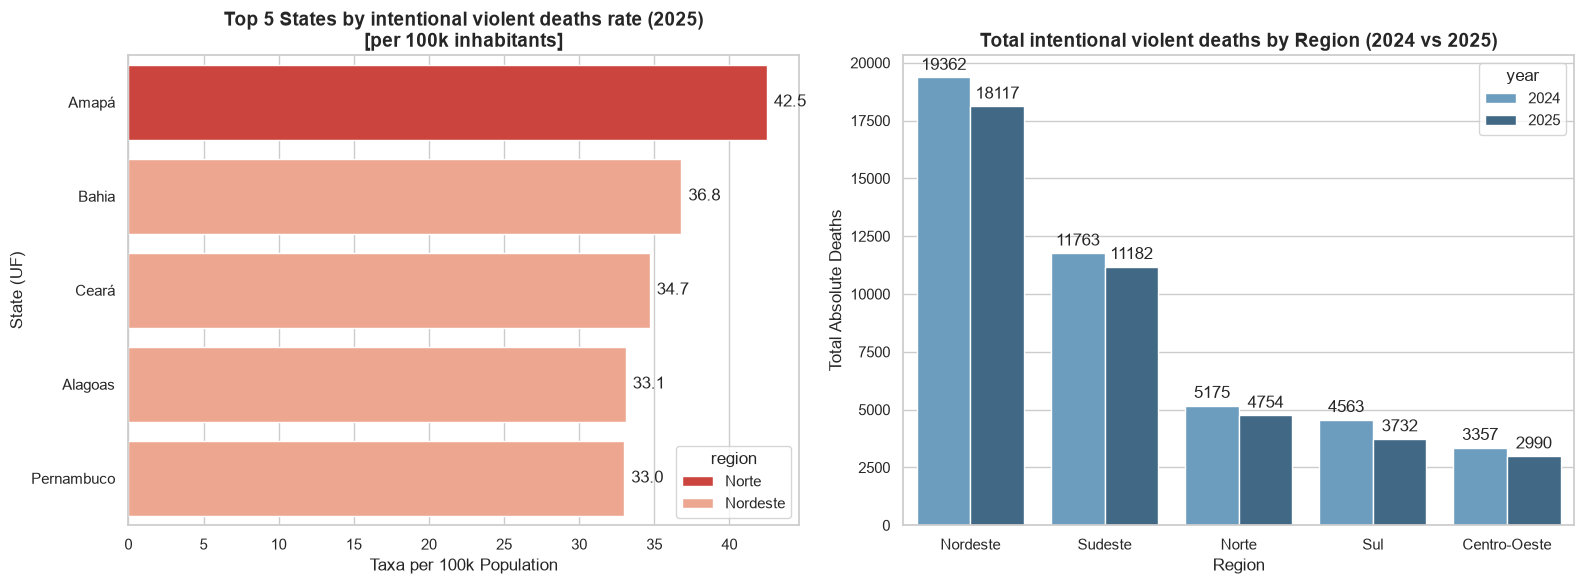

In [6]:
import duckdb
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 12})

# Connect to DuckDB
con = duckdb.connect()

# -------------------------------------------------------------------
# Query 1: Top 5 States with Highest MVI Rate in 2025
# -------------------------------------------------------------------
top5_query = """
SELECT 
    l.location_name AS state,
    l.region,
    f.value AS mvi_rate_2025
FROM 'data/3_gold/fct_mvi.parquet' f
JOIN 'data/3_gold/dim_location.parquet' l ON f.location_id = l.location_id
JOIN 'data/3_gold/dim_metric.parquet' m ON f.metric_id = m.metric_id
WHERE m.metric_code = 'mvi_taxa' 
  AND f.year = 2025 
  AND l.is_national = FALSE
ORDER BY mvi_rate_2025 DESC
LIMIT 5;
"""
df_top5 = con.execute(top5_query).df()

# -------------------------------------------------------------------
# Query 2: Regional Aggregation of Total MVI Deaths (2024 vs 2025)
# -------------------------------------------------------------------
region_query = """
SELECT 
    l.region,
    CAST(f.year AS VARCHAR) AS year,
    SUM(f.value) AS total_mvi_deaths
FROM 'data/3_gold/fct_mvi.parquet' f
JOIN 'data/3_gold/dim_location.parquet' l ON f.location_id = l.location_id
JOIN 'data/3_gold/dim_metric.parquet' m ON f.metric_id = m.metric_id
WHERE m.metric_code = 'mvi_absoluto' 
  AND l.is_national = FALSE
GROUP BY l.region, f.year
ORDER BY total_mvi_deaths DESC;
"""
df_region = con.execute(region_query).df()

# -------------------------------------------------------------------
# Plotting Figure with 2 Subplots
# -------------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Horizontal Bar Chart for Top 5 States
sns.barplot(
    data=df_top5,
    x='mvi_rate_2025',
    y='state',
    hue='region',
    dodge=False,
    ax=axes[0],
    palette='Reds_r'
)
axes[0].set_title('Top 5 States by intentional violent deaths rate (2025)\n[per 100k inhabitants]', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Taxa per 100k Population')
axes[0].set_ylabel('State (UF)')

# Add value labels inside bars
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%.1f', padding=5)

# Plot 2: Grouped Bar Chart for Regional Comparison (2024 vs 2025)
sns.barplot(
    data=df_region,
    x='region',
    y='total_mvi_deaths',
    hue='year',
    ax=axes[1],
    palette='Blues_d'
)
axes[1].set_title('Total intentional violent deaths by Region (2024 vs 2025)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Region')
axes[1].set_ylabel('Total Absolute Deaths')

# Add value labels on top of bars
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.0f', padding=3)

plt.tight_layout()
plt.show()